In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd

df = pd.read_csv(
r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_1_Data_Cleaning\Data\Raw_Data\ecommerce_sales_34500.csv"
)

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [3]:
missing_values = df.isnull().sum()

print(missing_values)

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64


In [4]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [5]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Admin\AppData\Local\Temp\ipykernel_29988\2688064643.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Admin\AppData\Local\Temp\ipykernel_29988\2688064643.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [7]:
categorical_columns = df.select_dtypes(include=['object']).columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_29988\110778351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [8]:
categorical_columns = df.select_dtypes(include=['string', 'object']).columns

print(categorical_columns)

Index(['order_id', 'customer_id', 'product_id', 'category', 'payment_method',
       'order_date', 'region', 'returned', 'customer_gender'],
      dtype='str')


In [9]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [10]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [11]:
df = df.drop_duplicates()

In [12]:
print("New Shape:", df.shape)

New Shape: (34500, 17)


In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  str           
 1   customer_id         34500 non-null  str           
 2   product_id          34500 non-null  str           
 3   category            34500 non-null  str           
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  str           
 8   order_date          34500 non-null  datetime64[us]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  str           
 11  returned            34500 non-null  str           
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64       
 14  p

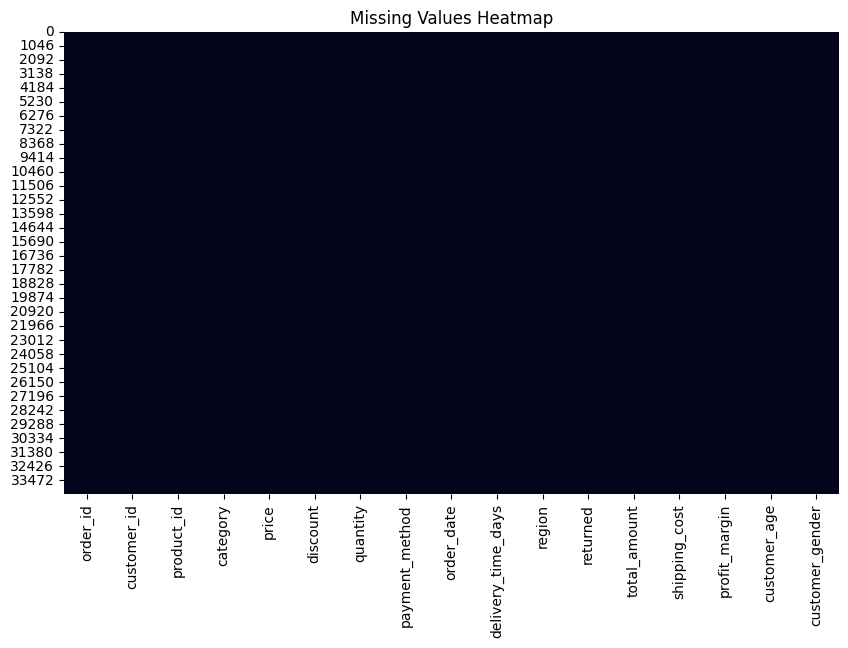

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

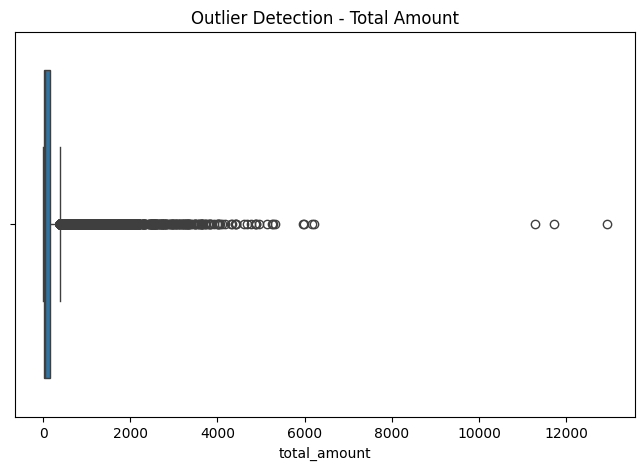

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['total_amount'])

plt.title("Outlier Detection - Total Amount")

plt.show()

In [17]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_cleaned = df[
    (df['total_amount'] >= lower_limit) &
    (df['total_amount'] <= upper_limit)
]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_cleaned.shape)

Original Shape: (34500, 17)
Cleaned Shape: (30708, 17)


In [18]:
df_cleaned.to_csv(
'../Data/Cleaned_Data/cleaned_ecommerce_sales.csv',
index=False
)

print("Cleaned dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\Data\Cleaned_Data'

In [19]:
df_cleaned.to_csv(
r"C:\Users\Admin\OneDrive\DataScience_Internship\DataScience_week2\Task_1_Data_Cleaning\Data\Cleaned_Data\cleaned_ecommerce_sales.csv",
index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [20]:
print(df_cleaned.shape)

(30708, 17)
